In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the cleaned dataset provided by the team
# Ensure 'cleaned_heart_data.csv' is in the same folder
df = pd.read_csv('cleaned_heart_data.csv')

# Display the first few rows to verify data
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [2]:
# Define Features (X) and Target (y)
# 'target' is the dependent variable (1 for disease, 0 for no disease)
X = df.drop('target', axis=1)
y = df['target']

print("Features and Target defined successfully.")
print(f"Features: {list(X.columns)}")

Features and Target defined successfully.
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [3]:
# Split the dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 820
Testing set size: 205


In [4]:
# Initialize and train the Decision Tree Classifier
# random_state=42 is used to ensure the results are reproducible
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model training completed successfully.")

Decision Tree model training completed successfully.


--- Decision Tree Model Evaluation ---
Accuracy Score: 98.54%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



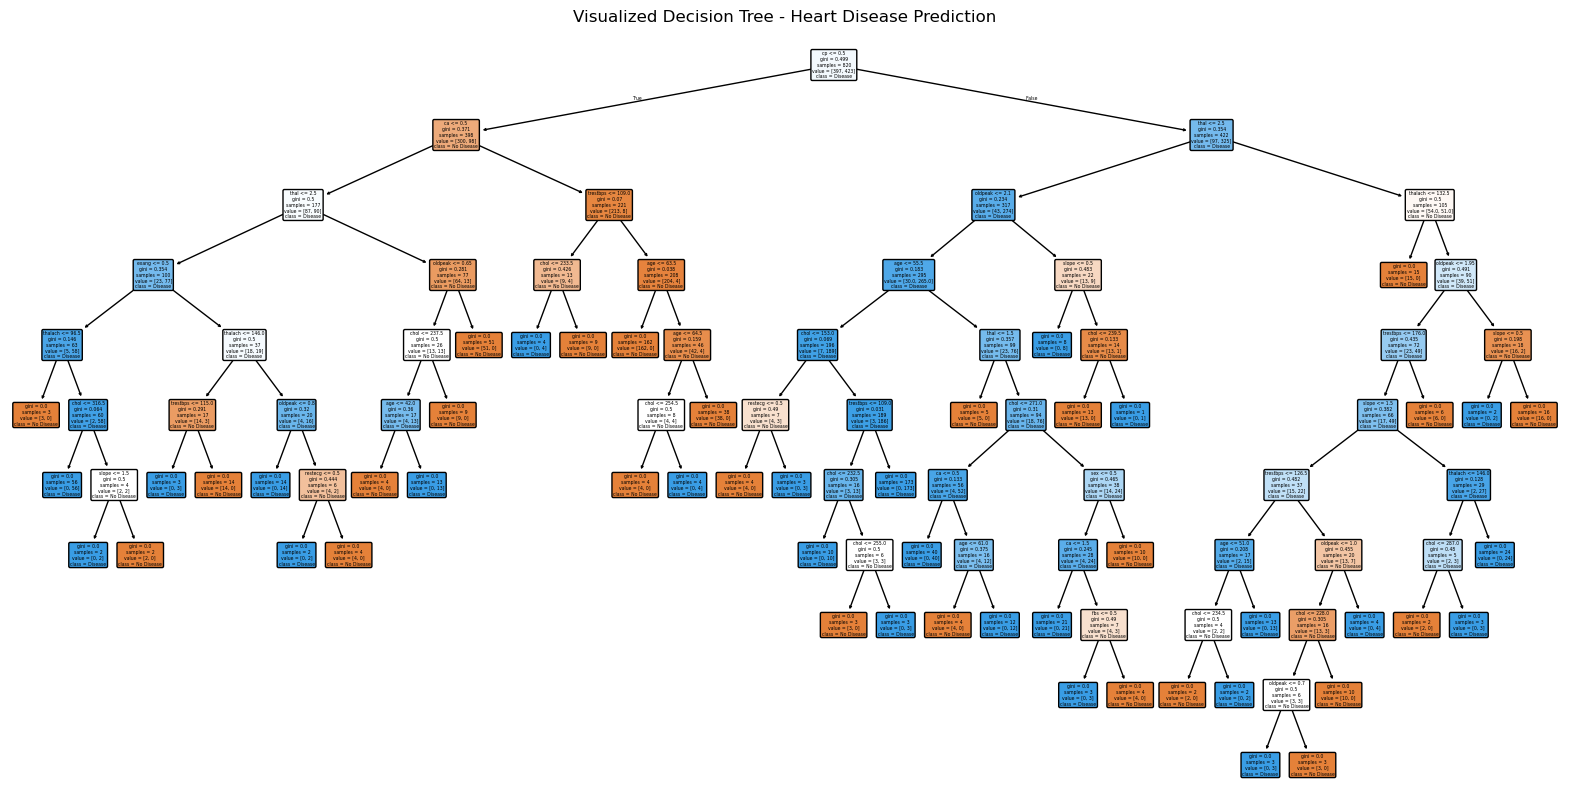

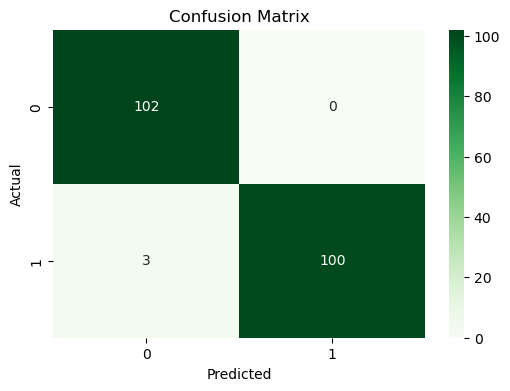

In [5]:
# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Calculate and display Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
print("--- Decision Tree Model Evaluation ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualize the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, feature_names=X.columns, 
          class_names=['No Disease', 'Disease'], rounded=True)
plt.title("Visualized Decision Tree - Heart Disease Prediction")
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()